In [1]:
# dataset @ https://finance.yahoo.com/quote/MSFT/history/

# If you want the exact same dataset as the YouTube video,
# use this link: https://drive.google.com/file/d/1WLm1AEYgU28Nk4lY4zNkGPSctdImbhJI/view?usp=sharing

In [52]:
import yfinance as yf
import pandas as pd

tickers = [
    "MSFT","AAPL","AMZN","TSLA","NVDA",        # US stocks
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS",  # Indian stocks
    "^GSPC","^NSEI"                     # indices
]

start = "1996-01-01"
end = "2026-01-01"

data = yf.download(
    tickers,
    start=start,
    end=end,
    group_by="ticker"
)

dfs = []

for ticker in tickers:
    df = data[ticker].copy()
    df["Ticker"] = ticker
    dfs.append(df)

combined = pd.concat(dfs)

combined.reset_index(inplace=True)

combined.to_csv("global_stock_dataset.csv", index=False)

print(combined.head())

[*********************100%***********************]  11 of 11 completed


Price       Date      Open      High       Low     Close       Volume Ticker
0     1996-01-01       NaN       NaN       NaN       NaN          NaN   MSFT
1     1996-01-02  3.347295  3.418717  3.328250  3.418717   57779200.0   MSFT
2     1996-01-03  3.394911  3.433003  3.304444  3.309205   62857600.0   MSFT
3     1996-01-04  3.323488  3.333011  3.233021  3.328249  102353600.0   MSFT
4     1996-01-05  3.285397  3.337773  3.280636  3.290159   62083200.0   MSFT


In [15]:
import pandas as pd

df = pd.read_csv('../datasets/global_stock_dataset.csv')

df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,1996-01-01,NaN,NaN,NaN,NaN,NaN,MSFT
1,1996-01-02,3.347295,3.418717,3.328250,3.418717,57779200.0,MSFT
2,1996-01-03,3.394911,3.433003,3.304444,3.309205,62857600.0,MSFT
3,1996-01-04,3.323488,3.333011,3.233021,3.328249,102353600.0,MSFT
4,1996-01-05,3.285397,3.337773,3.280636,3.290159,62083200.0,MSFT


In [16]:
df = df.dropna()
df = df.drop_duplicates()

In [17]:
df.head()

,Date,Open,High,Low,Close,Volume,Ticker
1,1996-01-02,3.347295,3.418717,3.328250,3.418717,57779200.0,MSFT
2,1996-01-03,3.394911,3.433003,3.304444,3.309205,62857600.0,MSFT
3,1996-01-04,3.323488,3.333011,3.233021,3.328249,102353600.0,MSFT
4,1996-01-05,3.285397,3.337773,3.280636,3.290159,62083200.0,MSFT
5,1996-01-08,3.294920,3.337773,3.280636,3.285397,11377600.0,MSFT


In [18]:
# reset index so Date becomes a column
df = df.reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,1996-01-02,3.347295,3.418717,3.328250,3.418717,57779200.0,MSFT
1,1996-01-03,3.394911,3.433003,3.304444,3.309205,62857600.0,MSFT
2,1996-01-04,3.323488,3.333011,3.233021,3.328249,102353600.0,MSFT
3,1996-01-05,3.285397,3.337773,3.280636,3.290159,62083200.0,MSFT
4,1996-01-08,3.294920,3.337773,3.280636,3.285397,11377600.0,MSFT


In [19]:
df = df[['Date','Close','Ticker']]

In [20]:
df.dtypes

Date          str
Close     float64
Ticker        str
dtype: object

In [21]:
df.dtypes

Date          str
Close     float64
Ticker        str
dtype: object

In [22]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [23]:
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

0       1996-01-02
1       1996-01-03
2       1996-01-04
3       1996-01-05
4       1996-01-08
           ...    
73417   2025-12-24
73418   2025-12-26
73419   2025-12-29
73420   2025-12-30
73421   2025-12-31
Name: Date, Length: 73422, dtype: datetime64[us]

In [24]:
df.index = df.pop('Date')
df

,Close,Ticker
Date,,
1996-01-02,3.418717,MSFT
1996-01-03,3.309205,MSFT
1996-01-04,3.328249,MSFT
1996-01-05,3.290159,MSFT
1996-01-08,3.285397,MSFT
...,...,...
2025-12-24,26142.099609,^NSEI
2025-12-26,26042.300781,^NSEI
2025-12-29,25942.099609,^NSEI


In [77]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

scaled_dfs = []
scalers = {}

cols = ['Close']

for ticker, group in df.groupby("Ticker"):

    scaler = MinMaxScaler()

    group[cols] = scaler.fit_transform(group[cols])

    scalers[ticker] = scaler   # save scaler

    scaled_dfs.append(group)

scaled_df = pd.concat(scaled_dfs)

In [78]:
import joblib

joblib.dump(scalers, "stock_scalers.pkl")

['stock_scalers.pkl']

In [28]:
df = scaled_df
df

,Close,Ticker
Date,,
1996-01-02,0.000503,AAPL
1996-01-03,0.000503,AAPL
1996-01-04,0.000488,AAPL
1996-01-05,0.000559,AAPL
1996-01-08,0.000568,AAPL
...,...,...
2025-12-24,0.996879,^NSEI
2025-12-26,0.992666,^NSEI
2025-12-29,0.988437,^NSEI


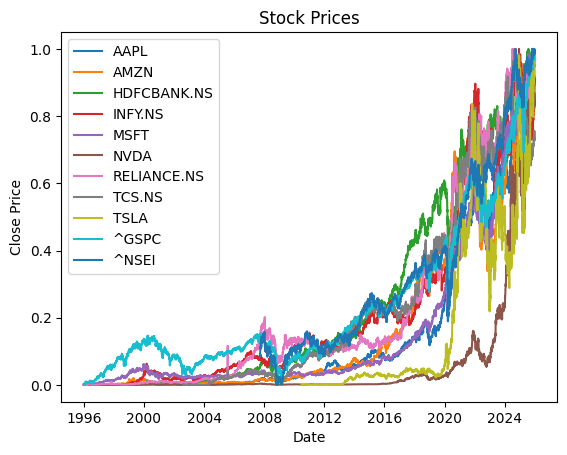

In [33]:
import matplotlib.pyplot as plt


for ticker, group in df.groupby("Ticker"):
    plt.plot(group.index, group['Close'], label=ticker)

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Stock Prices")
plt.legend()
plt.show()

##  Visual Example

### Dataset
```
Mar 22
Mar 23
Mar 24
Mar 25
Mar 26
Mar 29 ← next trading day
```

### For `n = 3`

Input: `[Mar22, Mar23, Mar24]`  
Target: `Mar25`

### Next iteration : find the next days in 7 days range in Mar 25 -> 25,26,29,.....

Input: `[Mar23, Mar24, Mar25]`  
Target: `Mar26`

### Next iteration : find the next days in 7 days range in Mar 26 -> 26,29,.....

Input: `[Mar24, Mar25, Mar26]`  
Target: `Mar29`


In [38]:
import numpy as np

def df_to_windowed_df(dataframe, first_date, last_date, n=3):
  # first_date = str_to_datetime(first_date_str)
  # last_date  = str_to_datetime(last_date_str)

  target_date = first_date

  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)

    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    # stock markets are closed on sat,sun adn holidays so no data available for those days
    # so we seach for the days which  falls in the next 7 days of the target date to choose the next trading date
    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)] 
    # chooses the next trading day top one is the previous trading day ,next one is the next trading day
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0]) 
    next_date_str = next_datetime_str.split('T')[0]
    next_date = str_to_datetime(next_date_str)

    if last_time:
      break

    target_date = next_date

    if target_date == last_date:
      last_time = True

  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]

  ret_df['Target'] = Y

  return ret_df

In [62]:
all_windows = []

for ticker, group in df.groupby("Ticker"):
    window_df = df_to_windowed_df(
        group,
        group.index[5],     # first valid date
        group.index[-1],
        n=5
    )

    window_df["Ticker"] = ticker

    all_windows.append(window_df)

final_dataset = pd.concat(all_windows)

In [63]:
tickers = final_dataset["Ticker"].values
final_dataset = final_dataset.drop("Ticker", axis=1)

In [64]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(final_dataset)

dates.shape, X.shape, y.shape

((73367,), (73367, 5, 1), (73367,))

In [66]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
# 80% → Training
# 10% → Validation
# 10% → Testing

dates_train, X_train, y_train, tickers_train = dates[:q_80], X[:q_80], y[:q_80], tickers[:q_80]
dates_val, X_val, y_val, tickers_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90], tickers[q_80:q_90]
dates_test, X_test, y_test, tickers_test = dates[q_90:], X[q_90:], y[q_90:], tickers[q_90:]

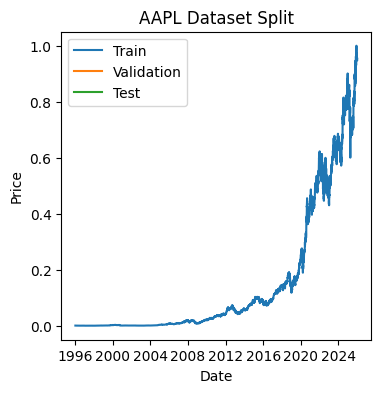

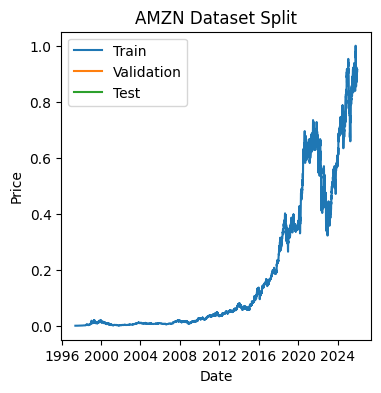

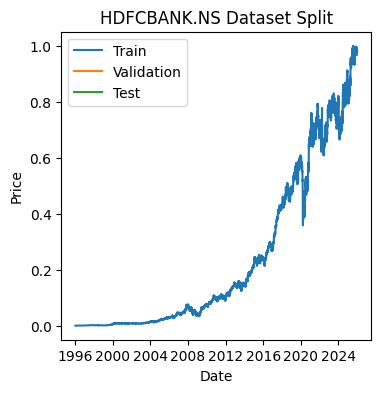

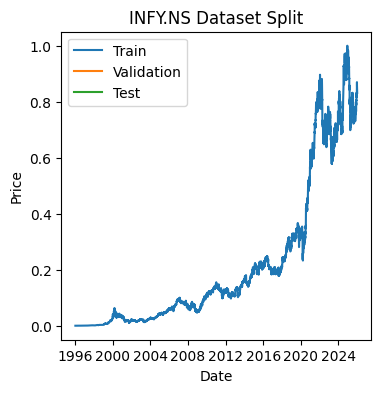

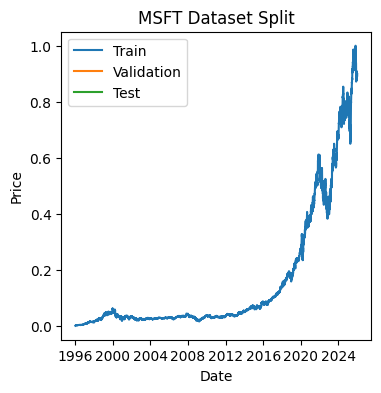

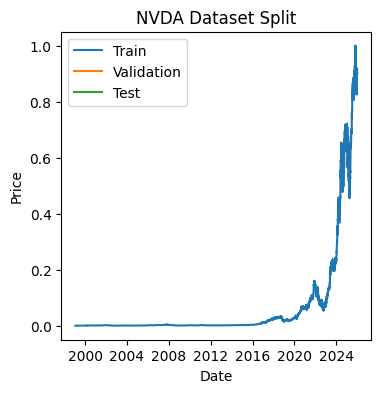

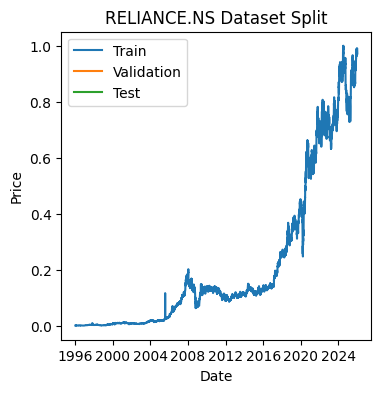

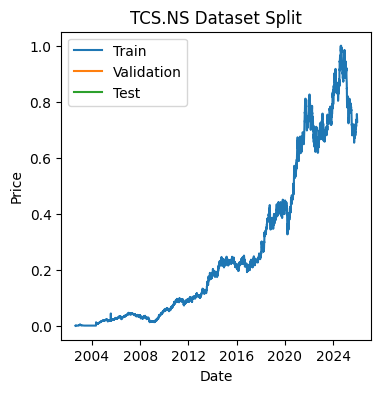

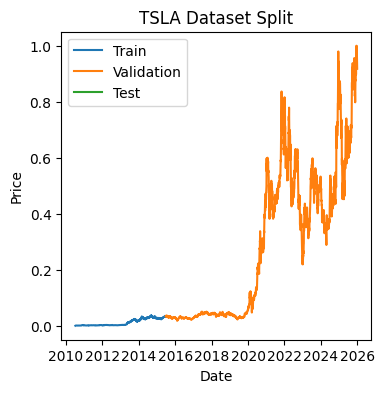

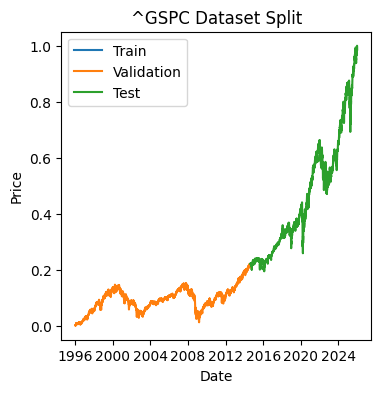

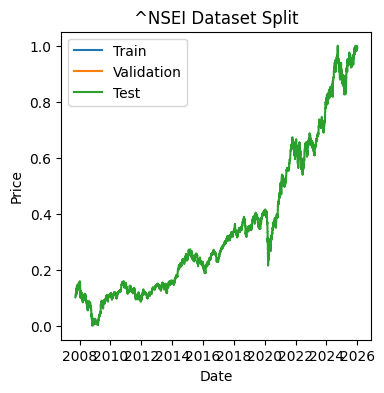

In [68]:
unique_tickers = np.unique(tickers)

for ticker in unique_tickers:
    
    plt.figure(figsize=(4,4))

    train_mask = tickers_train == ticker
    val_mask = tickers_val == ticker
    test_mask = tickers_test == ticker

    plt.plot(dates_train[train_mask], y_train[train_mask], label="Train")
    plt.plot(dates_val[val_mask], y_val[val_mask], label="Validation")
    plt.plot(dates_test[test_mask], y_test[test_mask], label="Test")

    plt.title(f"{ticker} Dataset Split")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()

    plt.show()

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((3, 1)),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 7.6466e-04 - mean_absolute_error: 0.0074 - val_loss: 1.9695e-04 - val_mean_absolute_error: 0.0075
Epoch 2/100
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7.3536e-05 - mean_absolute_error: 0.0050 - val_loss: 1.8368e-04 - val_mean_absolute_error: 0.0063
Epoch 3/100
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 6.0217e-05 - mean_absolute_error: 0.0045 - val_loss: 2.0058e-04 - val_mean_absolute_error: 0.0083
Epoch 4/100
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 4.9038e-05 - mean_absolute_error: 0.0040 - val_loss: 1.1909e-04 - val_mean_absolute_error: 0.0050
Epoch 5/100
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 4.1953e-05 - mean_absolute_error: 0.0037 - val_loss: 1.1450e-04 - val_mean_absolute_error: 0.0071
Epoch 6/100
1835/1835 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 3.9791e-05 - mean_absolute_error: 0.0037 - val_loss: 1.2005e-04 - val_mean_absolute_error: 0.0067
Epoch 7/100
1835/1835 ━━━━━━━━━━━

1835/1835 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


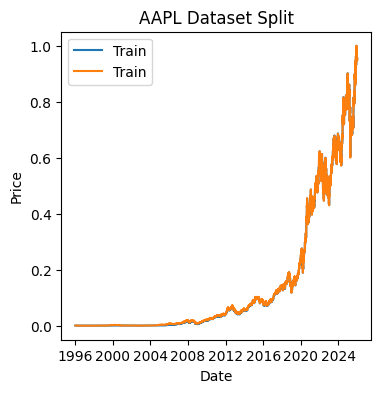

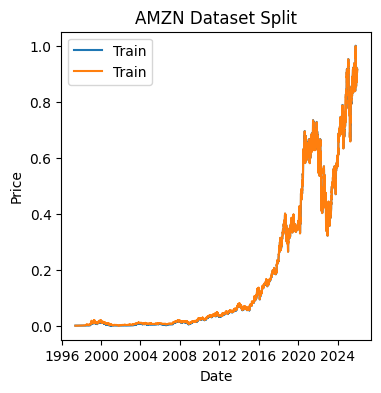

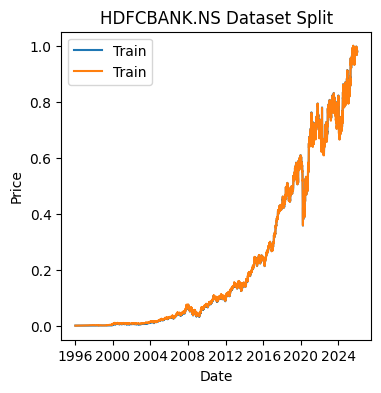

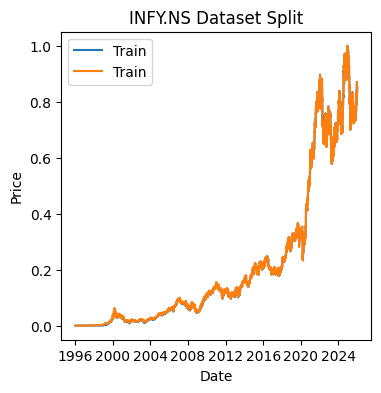

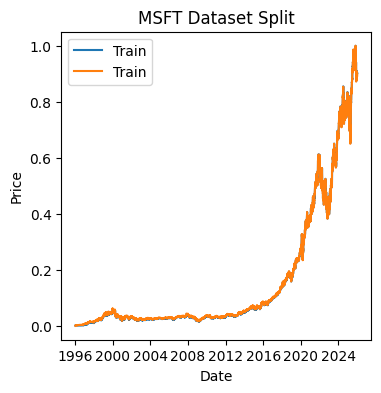

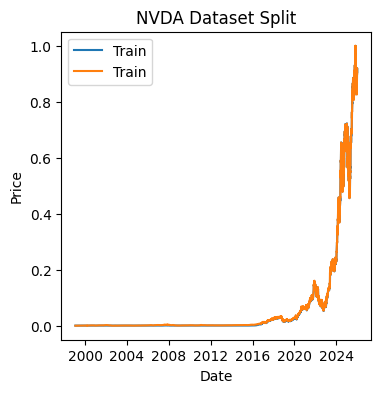

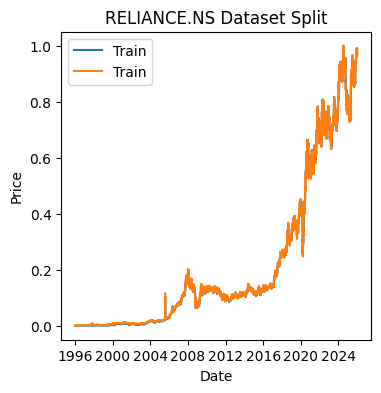

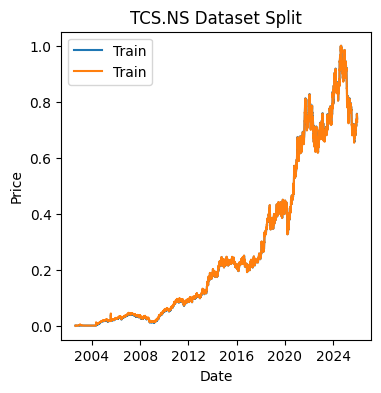

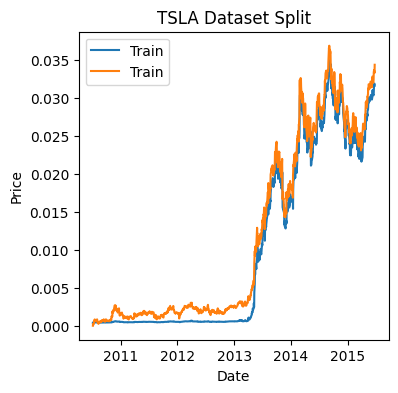

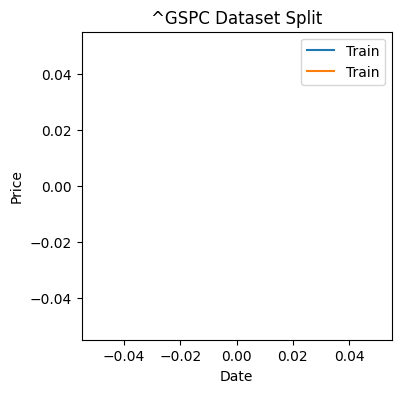

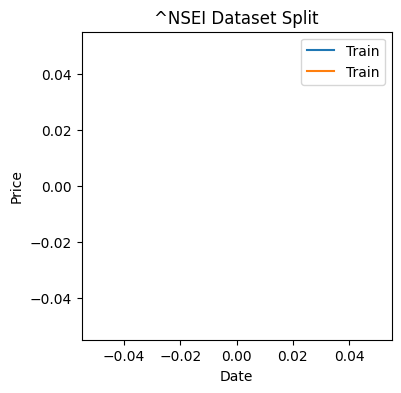

In [70]:
unique_tickers = np.unique(tickers)
train_predictions = model.predict(X_train).flatten()

for ticker in unique_tickers:
    
    plt.figure(figsize=(4,4))

    train_mask = tickers_train == ticker
    val_mask = tickers_val == ticker
    test_mask = tickers_test == ticker

    plt.plot(dates_train[train_mask], train_predictions[train_mask], label="Train")
    plt.plot(dates_train[train_mask], y_train[train_mask], label="Train")

    plt.title(f"{ticker} Dataset Split")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()

    plt.show()

230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


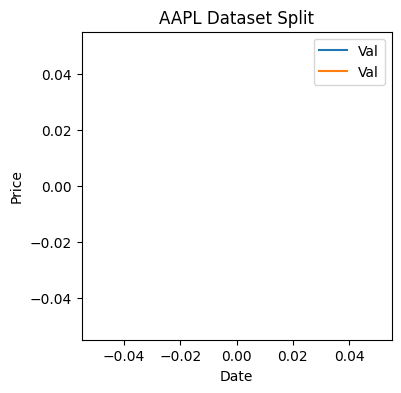

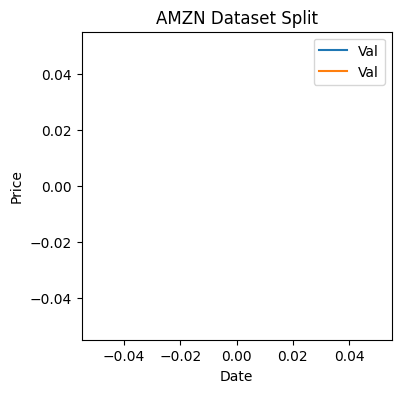

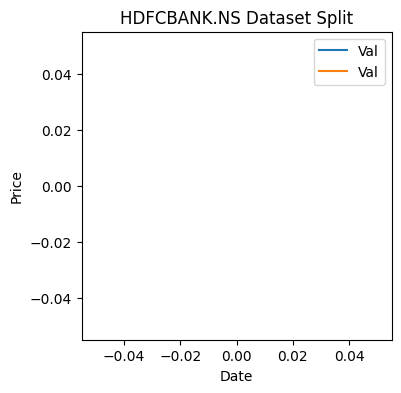

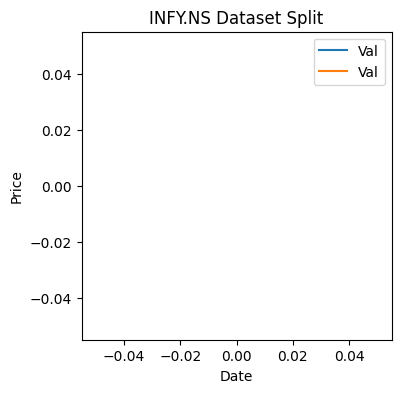

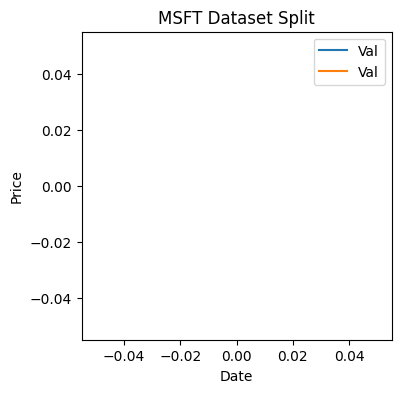

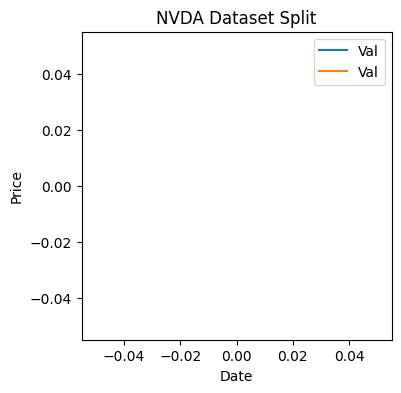

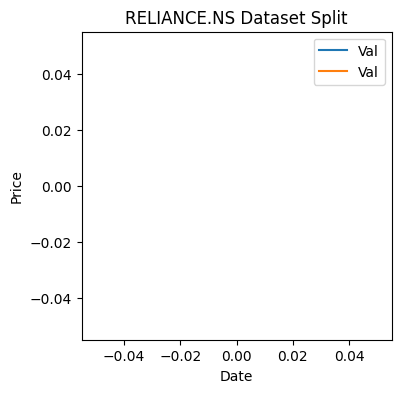

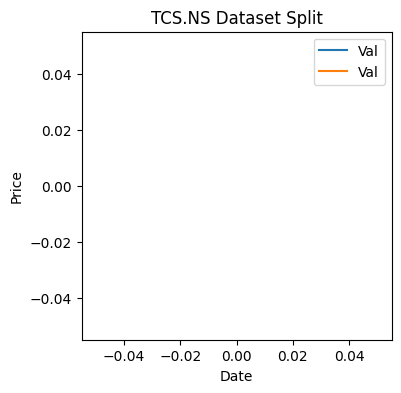

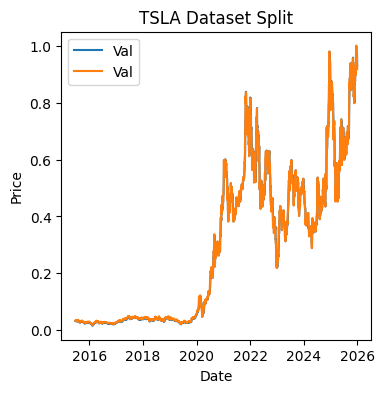

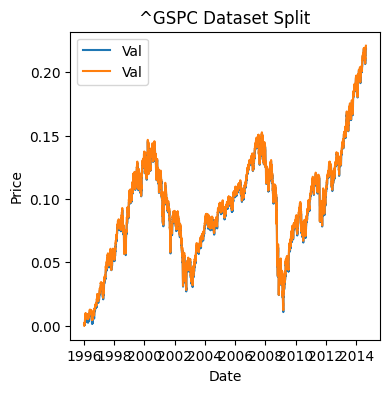

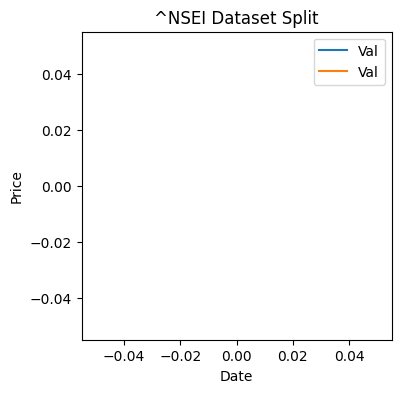

In [71]:
unique_tickers = np.unique(tickers)
val_predictions = model.predict(X_val).flatten()

for ticker in unique_tickers:
    
    plt.figure(figsize=(4,4))

    val_mask = tickers_val == ticker

    plt.plot(dates_val[val_mask], val_predictions[val_mask], label="Val")
    plt.plot(dates_val[val_mask], y_val[val_mask], label="Val")

    plt.title(f"{ticker} Dataset Split")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()

    plt.show()

230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


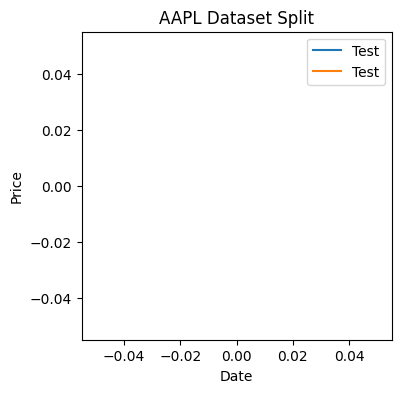

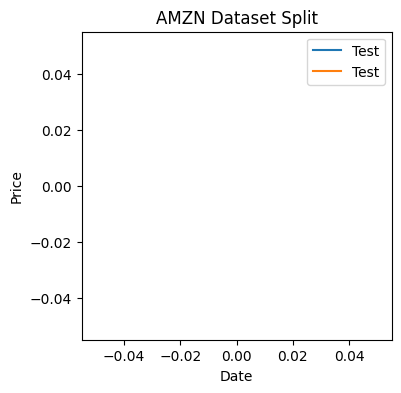

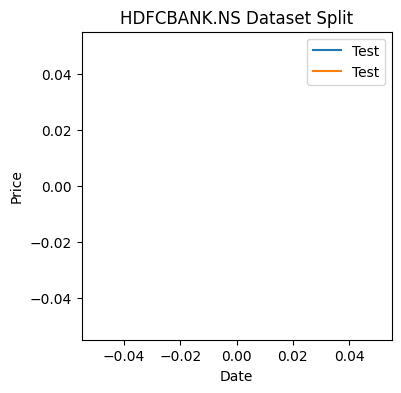

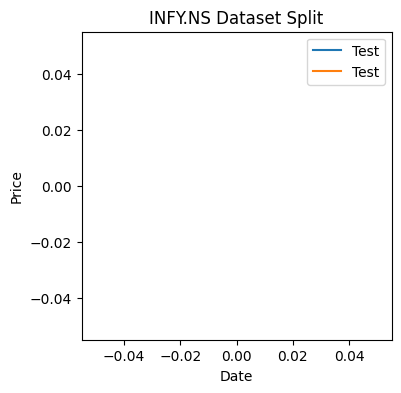

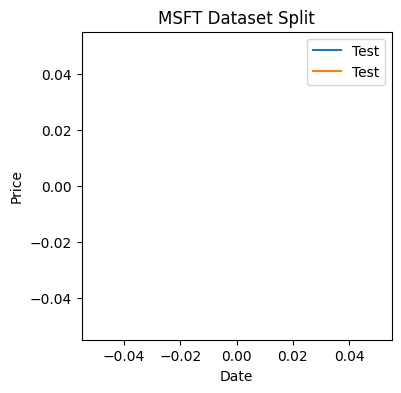

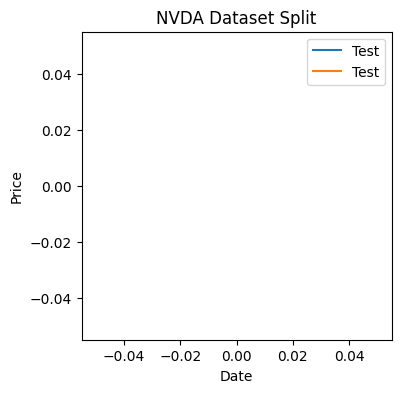

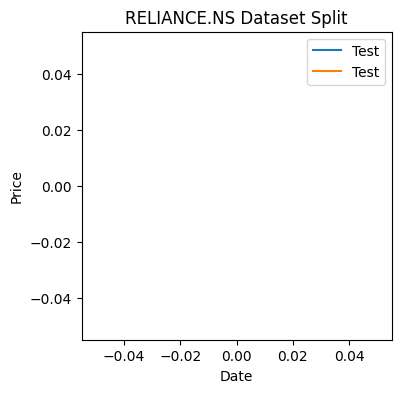

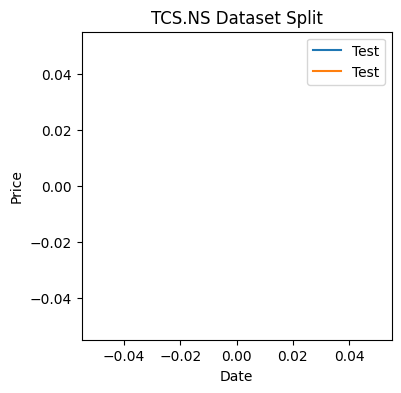

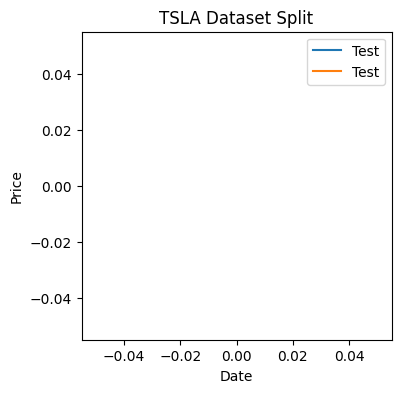

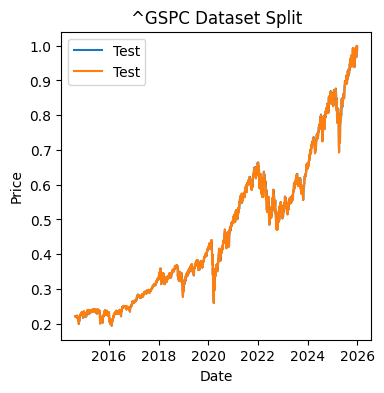

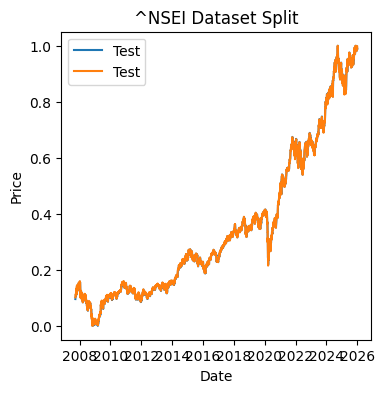

In [76]:
unique_tickers = np.unique(tickers)
test_predictions = model.predict(X_test).flatten()

for ticker in unique_tickers:
    
    plt.figure(figsize=(4,4))

    test_mask = tickers_test == ticker

    plt.plot(dates_test[test_mask], test_predictions[test_mask], label="Test")
    plt.plot(dates_test[test_mask], y_test[test_mask], label="Test")

    plt.title(f"{ticker} Dataset Split")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()

    plt.show()

In [74]:
model.save("general_stock_model.keras")